# **CREDIT DEFAULT**

## **1. LIBRERÍAS**





In [158]:
!pip install xgboost

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import fbeta_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import time
resultados_finales = []

## **2. LIMPIEZA DEL DATASET**

### **2.1 CARGA DEL DATASET Y EXPLORACIÓN DE VARIABLES**


In [160]:
df = pd.read_excel("credit_default.xlsx")
print("Dimensiones del dataset:", df.shape)
df.info()
df.describe()

Dimensiones del dataset: (3641, 129)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3641 entries, 0 to 3640
Columns: 129 entries, Número empleados 2008 to CONDICIONAL
dtypes: float64(128), int64(1)
memory usage: 3.6 MB


,Número empleados 2008,Número empleados 2009,Número empleados 2010,Número empleados 2011,MARGEN CAPADO 2008,MARGEN CAPADO 2009,MARGEN CAPADO 2010,MARGEN CAPADO 2011,RATIO LLIQUIDEZ CAPADO 2008,RATIO LLIQUIDEZ CAPADO 2009,...,Z SCORE 2011,COBERTURA DE TESORERÍA 2008,COBERTURA DE TESORERÍA 2009,COBERTURA DE TESORERÍA 2010,COBERTURA DE TESORERÍA 2011,TESORERÍA - ACTIVO CORRIENTE 2008,TESORERÍA - ACTIVO CORRIENTE 2009,TESORERÍA - ACTIVO CORRIENTE 2010,TESORERÍA - ACTIVO CORRIENTE 2011,CONDICIONAL
count,3069.000000,3025.000000,2848.000000,2356.000000,3069.000000,3025.000000,2848.000000,2356.000000,3069.000000,3025.000000,...,2356.000000,3069.000000,3025.000000,2848.000000,2356.000000,3.069000e+03,3.025000e+03,2.848000e+03,2.356000e+03,3641.000000
mean,144.784946,141.962645,145.653090,142.768251,0.026478,0.011964,0.020248,0.019769,2.702615,2.926830,...,39.934816,0.508547,0.648843,0.643706,1.885957,-1.566067e+04,-1.617370e+04,-1.485104e+04,-1.460626e+04,0.647075
std,483.607285,413.073488,427.147674,425.385176,0.140391,0.145062,0.146992,0.141547,7.367723,7.969728,...,970.358832,4.561687,11.790958,13.410830,60.210235,6.866259e+04,9.215782e+04,5.147026e+04,6.138505e+04,0.477945
min,0.000000,0.000000,0.000000,0.000000,-0.600000,-0.600000,-0.600000,-0.600000,0.000000,0.000000,...,-3.383093,0.000000,0.000000,0.000000,0.000000,-2.539000e+06,-3.678000e+06,-1.218747e+06,-1.926000e+06,0.000000
25%,28.000000,29.000000,30.000000,28.000000,0.000545,-0.009806,0.000113,0.000000,1.074928,1.086675,...,3.493818,0.015669,0.020118,0.020324,0.021399,-1.006656e+04,-9.398054e+03,-9.827302e+03,-8.838724e+03,0.000000
50%,56.000000,56.000000,58.000000,54.000000,0.016742,0.011468,0.014739,0.012518,1.492513,1.536913,...,5.799765,0.065185,0.078947,0.081110,0.081541,-3.693047e+03,-3.335616e+03,-3.630301e+03,-3.247369e+03,1.000000
75%,112.000000,116.000000,117.250000,112.000000,0.053503,0.044986,0.049128,0.046557,2.348767,2.500832,...,10.330823,0.251789,0.314587,0.284357,0.304778,-1.445562e+03,-1.285108e+03,-1.433130e+03,-1.230290e+03,1.000000
max,13923.000000,9899.000000,9291.000000,9538.000000,0.600000,0.600000,0.600000,0.600000,100.000000,100.000000,...,46367.922654,148.011966,627.728424,708.512195,2903.060194,9.820517e+04,9.059200e+04,8.702400e+04,4.426700e+04,1.000000


### **2.2 EXPLORACIÓN DE NULOS Y ELIMINACIÓN DE COLUMNAS**

In [161]:
df = df.fillna(0) #Se sustituyen los nulos por 0, ya que en este caso aportan información
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

,0


In [162]:
columnas_eliminar = [
# PIB
"PIB 2008",
"PIB 2009",
"PIB 2010",
"PIB 2011",
# ROA industria
"ROA industria Y AÑO 2008",
"ROA industria Y AÑO 2009",
"ROA industria Y AÑO 2010",
"ROA industria Y AÑO 2011",
# Diferencia ROA
"Diferencia ROA empresa y ROA sector 2008",
"Diferencia ROA empresa y ROA sector 2009",
"Diferencia ROA empresa y ROA sector 2010",
"Diferencia ROA empresa y ROA sector 2011",
# Current ratio
"Current ratio - liquidez (ac/pc) 2008",
"Current ratio - liquidez (ac/pc) 2009",
"Current ratio - liquidez (ac/pc) 2010",
"Current ratio - liquidez (ac/pc) 2011",
]
df = df.drop(columns=columnas_eliminar)

In [163]:
columnas_2011 = [
    col for col in df.columns
    if "2011" in col
]

print("Columnas eliminadas:")
print(columnas_2011)

df = df.drop(columns=columnas_2011)

print("\nNuevo tamaño del dataset:")
print(df.shape)

Columnas eliminadas:
['Número empleados 2011', 'MARGEN CAPADO 2011', 'RATIO LLIQUIDEZ CAPADO 2011', 'ROA EMPRESA CAPADO 2011', 'ROA Relativo 2011', 'ROE CAPADO 2011', 'VPIB/VVENTAS 2011', 'PMA_CAPADO 2011', 'VPMA 2011', 'PMC_CAPADO 2011', 'VPMC 2011', 'PMP_CAPADO 2011', 'VPMP 2011', 'PMM_CAPADO 2011', 'DEUDA/PASIVO 2011', 'CAPEX (INVERSION EN ACTIVOS NO CORRIENTES) 2011', 'RENTABILIDAD CAPADO 2011', 'Rentabilidad esperada/real (ROA) 2011 CAPADO', 'ratio de endeudamiento (DEUDA/PATRIMONIO NETO) CAPADO_1 2011', 'ESTRUCTURA DE COSTES FIJOS 2011', 'NOF (NECESIDADES OPERATIVAS DE FONDOS) 2011', 'CAPEX 2011', 'FREE CASH FLOW 2011', 'FCF / EBITDA 2011', 'FONDO DE MANIOBRA CAPADO 2011', 'Z SCORE 2011', 'COBERTURA DE TESORERÍA 2011', 'TESORERÍA - ACTIVO CORRIENTE 2011']

Nuevo tamaño del dataset:
(3641, 85)


### **2.3 SEPARACIÓN ENTRE X E Y (VARIABLE OBJETIVO)**

In [164]:
X = df.drop(columns=["CONDICIONAL"])
y = df["CONDICIONAL"]
print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)
conteo_y = pd.DataFrame({
    "Cantidad": y.value_counts(),
    "Porcentaje": y.value_counts(normalize=True) * 100
})

Variables predictoras: (3641, 84)
Variable objetivo: (3641,)


### **2.4 DIVISIÓN TRAIN-TEST Y ESCALADO**

In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (2912, 84)
Test: (729, 84)


### **2.4 FUNCIÓN DE EVALUACIÓN PARA TODOS LOS MODELOS**

In [166]:
def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    resultados = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": auc
    }

    print(f"\n===== {nombre_modelo} =====")
    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    return resultados

## **3. REGRESION LOGÍSTICA**

### **3.1 DEFINICIÓN DE PARÁMETROS**

In [167]:
inicio_lr = time.time()
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, random_state=42)

### **3.2 PREDICCIONES Y MÉTRICAS**

In [168]:
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.01, 0.99, 0.01)

resultados_threshold_lr = []

for threshold in thresholds:

    y_pred_temp = (y_prob_lr >= threshold).astype(int)

    resultados_threshold_lr.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_temp),
        "Precision": precision_score(y_test, y_pred_temp, zero_division=0),
        "Recall": recall_score(y_test, y_pred_temp, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_temp, zero_division=0),
        "F2-score": fbeta_score(y_test, y_pred_temp, beta=2, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob_lr)
    })

resultados_threshold_lr_df = pd.DataFrame(resultados_threshold_lr)

candidatos_lr = resultados_threshold_lr_df[
    resultados_threshold_lr_df["Recall"] >= 0.90
]

mejor_threshold_lr = candidatos_lr.sort_values(
    by="Precision",
    ascending=False
).iloc[0]["Threshold"]

print("Mejor threshold:", mejor_threshold_lr)

y_pred_lr = (y_prob_lr >= mejor_threshold_lr).astype(int)
tiempo_lr = time.time() - inicio_lr

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
f2_lr = fbeta_score(y_test, y_pred_lr, beta=2, zero_division=0)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("===== Regresión Logística =====")
print("Mejor threshold:", mejor_threshold_lr)
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1-score:", f1_lr)
print("F2-score:", f2_lr)
print("AUC-ROC:", auc_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

resultados_finales.append({
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1-score": f1_lr,
    "F2-score": f2_lr,
    "AUC-ROC": auc_lr,
    "Tiempo (s)": tiempo_lr
})

Mejor threshold: 0.48000000000000004
===== Regresión Logística =====
Mejor threshold: 0.48000000000000004
Accuracy: 0.7256515775034293
Precision: 0.7352941176470589
Recall: 0.9004237288135594
F1-score: 0.8095238095238095
F2-score: 0.8617193836171938
AUC-ROC: 0.714617819692673

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.40      0.51       257
           1       0.74      0.90      0.81       472

    accuracy                           0.73       729
   macro avg       0.71      0.65      0.66       729
weighted avg       0.72      0.73      0.70       729



### **3.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

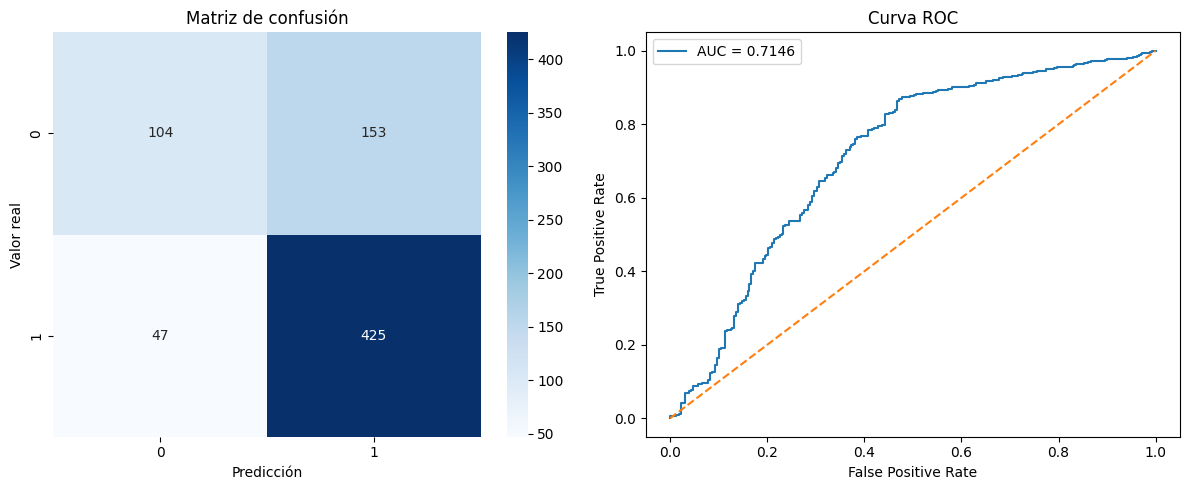

In [169]:
cm = confusion_matrix(y_test, y_pred_lr)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

auc = roc_auc_score(y_test, y_prob_lr)
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)
ax[1].plot([0,1], [0,1], linestyle="--")
ax[1].set_title("Curva ROC")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **3.4 IMPORTANCIA DE VARIABLES**

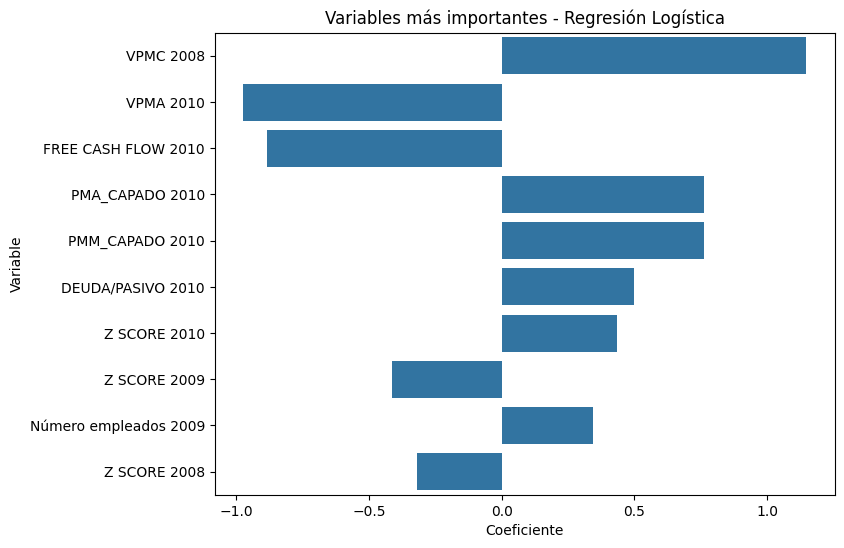

In [170]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_reg.coef_[0]
})

coeficientes["Valor absoluto"] = abs(coeficientes["Coeficiente"])
coeficientes = coeficientes.sort_values(
    by="Valor absoluto",
    ascending=False
)
top10 = coeficientes.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    data=top10,
    x="Coeficiente",
    y="Variable"
)
plt.title("Variables más importantes - Regresión Logística")
plt.show()

## **4. k-NEAREST NEIGHBORS (k-NN)**

### **4.1 DEFINICIÓN DE PARÁMETROS**

In [171]:
inicio_knn = time.time()
resultados_knn = []
valores_k = range(1, 31)
metricas = ["euclidean", "manhattan"]

for k in valores_k:
    for metrica in metricas:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights="distance",
            metric=metrica
        )
        knn.fit(X_train_scaled, y_train)
        y_prob = knn.predict_proba(X_test_scaled)[:,1]
        thresholds = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
        for threshold in thresholds:
            y_pred = (y_prob >= threshold).astype(int)
            resultados_knn.append({
                "k": k,
                "Métrica": metrica,
                "Threshold": threshold,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1-score": f1_score(y_test, y_pred, zero_division=0),
                "F2-score": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
                "AUC-ROC": roc_auc_score(y_test, y_prob)
            })
resultados_knn_df = pd.DataFrame(resultados_knn)
candidatos_knn = resultados_knn_df[
    resultados_knn_df["Recall"] >= 0.90
]
mejor_knn = candidatos_knn.sort_values(
    by="Precision",
    ascending=False
).iloc[0]
best_k = int(mejor_knn["k"])
best_metric = mejor_knn["Métrica"]
best_threshold = mejor_knn["Threshold"]
print(mejor_knn)
knn_final = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="distance",
    metric=best_metric
)
knn_final.fit(X_train_scaled, y_train)

k                   16
Métrica      manhattan
Threshold          0.5
Accuracy      0.757202
Precision     0.763864
Recall        0.904661
F1-score      0.828322
F2-score      0.872497
AUC-ROC       0.737024
Name: 255, dtype: object


KNeighborsClassifier(metric='manhattan', n_neighbors=16, weights='distance')

### **4.2 PREDICCIONES Y MÉTRICAS**

In [172]:
y_prob_knn = knn_final.predict_proba(X_test_scaled)[:,1]
y_pred_knn = (y_prob_knn >= best_threshold).astype(int)
tiempo_knn = time.time() - inicio_knn

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
f2_knn = fbeta_score(y_test, y_pred_knn, beta=2, zero_division=0)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("===== k-NN =====")
print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-score:", f1_knn)
print("F2-score:", f2_knn)
print("AUC-ROC:", auc_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

resultados_finales.append({
    "Modelo": "k-NN",
    "Accuracy": accuracy_knn,
    "Precision": precision_knn,
    "Recall": recall_knn,
    "F1-score": f1_knn,
    "F2-score": f2_knn,
    "AUC-ROC": auc_knn,
    "Tiempo (s)": tiempo_knn
})

===== k-NN =====
Accuracy: 0.757201646090535
Precision: 0.7638640429338104
Recall: 0.9046610169491526
F1-score: 0.8283220174587779
F2-score: 0.8724969350224765
AUC-ROC: 0.7370243355536503

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.49      0.59       257
           1       0.76      0.90      0.83       472

    accuracy                           0.76       729
   macro avg       0.75      0.70      0.71       729
weighted avg       0.75      0.76      0.74       729



### **4.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

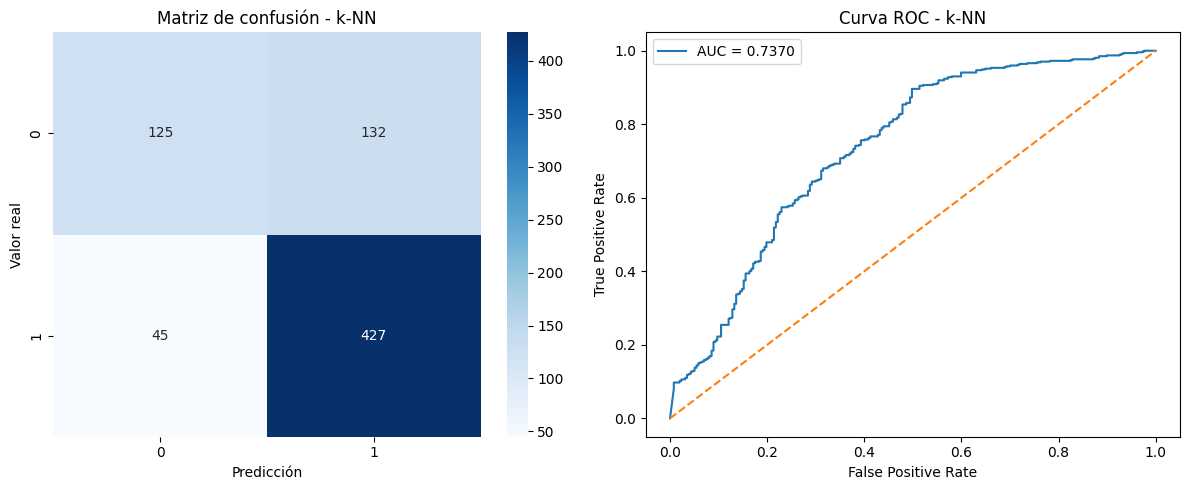

In [173]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - k-NN")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_knn,
    tpr_knn,
    label=f"AUC = {auc_knn:.4f}"
)
ax[1].plot([0,1], [0,1], linestyle="--")
ax[1].set_title("Curva ROC - k-NN")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

## **5. ÁRBOLES DE DECISIÓN**

### **5.1 DEFINICIÓN DE PARÁMETROS**




In [174]:
inicio_tree = time.time()
resultados_tree = []
valores_depth = [3, 5, 7, 10]
valores_leaf = [1, 5, 10, 20]
valores_split = [2, 10, 20]
thresholds = np.arange(0.01, 0.99, 0.01)
for depth in valores_depth:
    for leaf in valores_leaf:
        for split in valores_split:
            tree = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_leaf=leaf,
                min_samples_split=split,
                random_state=42
            )
            tree.fit(X_train, y_train)
            y_prob = tree.predict_proba(X_test)[:, 1]
            for threshold in thresholds:
                y_pred = (y_prob >= threshold).astype(int)
                resultados_tree.append({
                    "max_depth": depth,
                    "min_samples_leaf": leaf,
                    "min_samples_split": split,
                    "threshold": threshold,
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "F1-score": f1_score(y_test, y_pred, zero_division=0),
                    "F2-score": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
                    "AUC-ROC": roc_auc_score(y_test, y_prob)
                })
resultados_tree_df = pd.DataFrame(resultados_tree)
candidatos_tree = resultados_tree_df[
    resultados_tree_df["Recall"] >= 0.90
]
mejor_tree = candidatos_tree.sort_values(
    by="Precision",
    ascending=False
).iloc[0]
best_depth = int(mejor_tree["max_depth"])
best_leaf = int(mejor_tree["min_samples_leaf"])
best_split = int(mejor_tree["min_samples_split"])
best_threshold = mejor_tree["threshold"]
print(mejor_tree)
tree_final = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    min_samples_split=best_split,
    random_state=42
)
tree_final.fit(X_train, y_train)

max_depth             3.000000
min_samples_leaf     10.000000
min_samples_split    20.000000
threshold             0.410000
Accuracy              0.759945
Precision             0.767568
Recall                0.902542
F1-score              0.829601
F2-score              0.871879
AUC-ROC               0.731847
Name: 824, dtype: float64


DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

### **5.2 PREDICCIONES Y MÉTRICAS**

In [175]:
y_prob_tree = tree_final.predict_proba(X_test)[:,1]
y_pred_tree = (y_prob_tree >= best_threshold).astype(int)
tiempo_tree = time.time() - inicio_tree

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
f2_tree = fbeta_score(y_test, y_pred_tree, beta=2)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("===== ÁRBOL DE DECISIÓN =====\n")
print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)
print("F2-score:", f2_tree)
print("AUC-ROC:", auc_tree)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_tree))


resultados_finales.append({
    "Modelo": "Árbol de Decisión",
    "Accuracy": accuracy_tree,
    "Precision": precision_tree,
    "Recall": recall_tree,
    "F1-score": f1_tree,
    "F2-score": f2_tree,
    "AUC-ROC": auc_tree,
    "Tiempo (s)": tiempo_tree
})

===== ÁRBOL DE DECISIÓN =====

Accuracy: 0.7599451303155007
Precision: 0.7675675675675676
Recall: 0.902542372881356
F1-score: 0.8296007789678675
F2-score: 0.8718788374948834
AUC-ROC: 0.7318472597770889

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.74      0.50      0.59       257
           1       0.77      0.90      0.83       472

    accuracy                           0.76       729
   macro avg       0.75      0.70      0.71       729
weighted avg       0.76      0.76      0.75       729



### **5.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

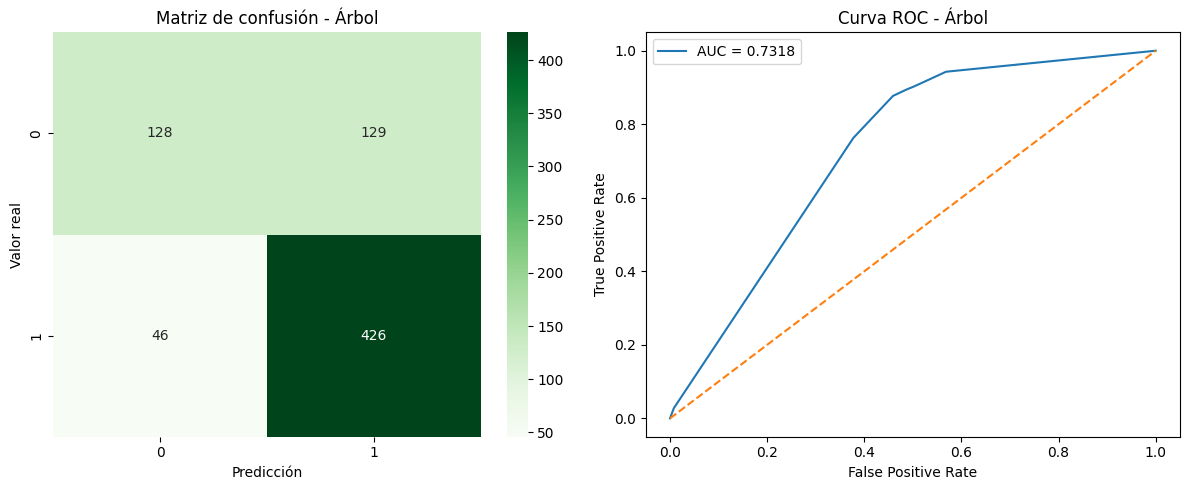

In [176]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_prob_tree
)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# MATRIZ

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - Árbol")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

# ROC

ax[1].plot(
    fpr_tree,
    tpr_tree,
    label=f"AUC = {auc_tree:.4f}"
)

ax[1].plot([0,1], [0,1], linestyle="--")

ax[1].set_title("Curva ROC - Árbol")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")

ax[1].legend()

plt.tight_layout()
plt.show()

### **5.4 IMPORTANCIA DE VARIABLES**

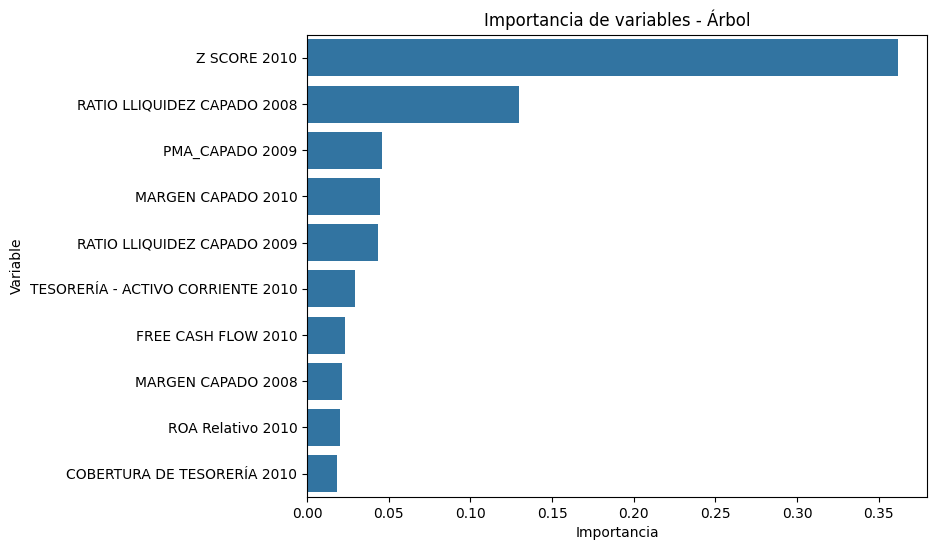

In [177]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": tree.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias.head(10)
top10 = importancias.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Árbol")

plt.show()

## **6. RANDOM FOREST**

### **6.1 DEFINICIÓN DE PARÁMETROS**

In [178]:
inicio_rf = time.time()

resultados_rf = []

valores_estimators = [100, 200, 300]
valores_depth = [5, 10, 20, None]
valores_leaf = [1, 5, 10]

thresholds = np.arange(0.01, 0.99, 0.01)

for n in valores_estimators:
    for depth in valores_depth:
        for leaf in valores_leaf:

            rf = RandomForestClassifier(
                n_estimators=n,
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42,
                n_jobs=-1
            )

            rf.fit(X_train, y_train)

            y_prob = rf.predict_proba(X_test)[:, 1]

            for threshold in thresholds:

                y_pred = (y_prob >= threshold).astype(int)

                resultados_rf.append({
                    "n_estimators": n,
                    "max_depth": depth,
                    "min_samples_leaf": leaf,
                    "threshold": threshold,
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "F1-score": f1_score(y_test, y_pred, zero_division=0),
                    "F2-score": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
                    "AUC-ROC": roc_auc_score(y_test, y_prob)
                })

resultados_rf_df = pd.DataFrame(resultados_rf)

candidatos_rf = resultados_rf_df[
    resultados_rf_df["Recall"] >= 0.95
]

if len(candidatos_rf) > 0:
    mejor_rf = candidatos_rf.sort_values(
        by="Precision",
        ascending=False
    ).iloc[0]
else:
    mejor_rf = resultados_rf_df.sort_values(
        by="F2-score",
        ascending=False
    ).iloc[0]

print(mejor_rf)

best_n = int(mejor_rf["n_estimators"])
best_depth = mejor_rf["max_depth"]

if pd.notnull(best_depth):
    best_depth = int(best_depth)
else:
    best_depth = None

best_leaf = int(mejor_rf["min_samples_leaf"])
best_threshold = mejor_rf["threshold"]

rf_final = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

n_estimators        100.000000
max_depth            10.000000
min_samples_leaf     10.000000
threshold             0.330000
Accuracy              0.751715
Precision             0.739703
Recall                0.951271
F1-score              0.832252
F2-score              0.899800
AUC-ROC               0.783676
Name: 522, dtype: float64


RandomForestClassifier(max_depth=10, min_samples_leaf=10, n_jobs=-1,
                       random_state=42)

### **6.2 PREDICCIONES Y MÉTRICAS**

In [179]:
y_prob_rf = rf_final.predict_proba(X_test)[:,1]
y_pred_rf = (y_prob_rf >= best_threshold).astype(int)
tiempo_rf = time.time() - inicio_rf

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
f2_rf = fbeta_score(y_test, y_pred_rf, beta=2)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("===== RANDOM FOREST =====\n")

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)
print("F2-score:", f2_rf)
print("AUC-ROC:", auc_rf)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_rf))

resultados_finales.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-score": f1_rf,
    "F2-score": f2_rf,
    "AUC-ROC": auc_rf,
    "Tiempo (s)": tiempo_rf
})

===== RANDOM FOREST =====

Accuracy: 0.7517146776406035
Precision: 0.7397034596375618
Recall: 0.951271186440678
F1-score: 0.8322520852641334
F2-score: 0.8997995991983968
AUC-ROC: 0.7836757238013586

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.81      0.39      0.52       257
           1       0.74      0.95      0.83       472

    accuracy                           0.75       729
   macro avg       0.78      0.67      0.68       729
weighted avg       0.77      0.75      0.72       729



### **6.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

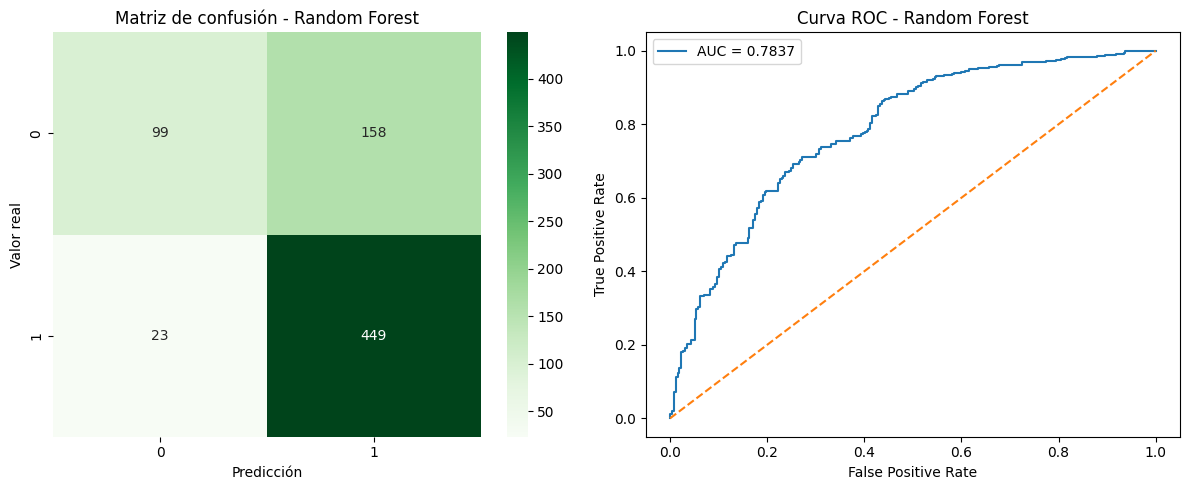

In [180]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - Random Forest")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {auc_rf:.4f}"
)
ax[1].plot([0, 1], [0, 1], linestyle="--")
ax[1].set_title("Curva ROC - Random Forest")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **6.4 IMPORTANCIA DE VARIABLES**

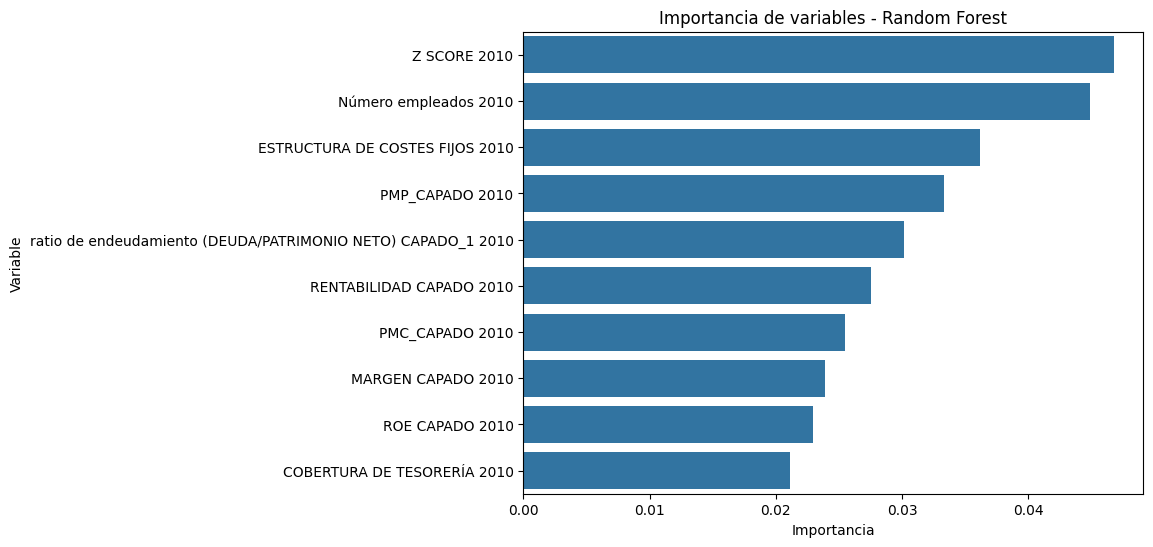

In [181]:
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by="Importancia",
    ascending=False
)

top10_rf = importancias_rf.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10_rf,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## **7. XGBOOST**

### **7.1 DEFINICIÓN DE PARÁMETROS**

In [182]:
inicio_xgb = time.time()

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 2, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(xgb_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores hiperparámetros:
{'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [183]:
xgb_final = xgb_search.best_estimator_
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.01, 0.99, 0.01)
resultados_threshold_xgb = []
for threshold in thresholds:
    y_pred_temp = (y_prob_xgb >= threshold).astype(int)
    resultados_threshold_xgb.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_temp),
        "Precision": precision_score(y_test, y_pred_temp, zero_division=0),
        "Recall": recall_score(y_test, y_pred_temp, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_temp, zero_division=0),
        "F2-score": fbeta_score(y_test, y_pred_temp, beta=2, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob_xgb)
    })
resultados_threshold_xgb_df = pd.DataFrame(resultados_threshold_xgb)
candidatos_xgb = resultados_threshold_xgb_df[
    resultados_threshold_xgb_df["Recall"] >= 0.95
]
if len(candidatos_xgb) > 0:
    mejor_threshold_xgb = candidatos_xgb.sort_values(
        by="Precision",
        ascending=False
    ).iloc[0]["Threshold"]

else:

    mejor_threshold_xgb = resultados_threshold_xgb_df.sort_values(
        by="F2-score",
        ascending=False
    ).iloc[0]["Threshold"]

print("Mejor threshold:", mejor_threshold_xgb)

Mejor threshold: 0.42000000000000004


### **7.2 PREDICCIONES Y MÉTRICAS**

In [184]:
xgb_final = xgb_search.best_estimator_
y_pred_xgb = xgb_final.predict(X_test)
tiempo_xgb = time.time() - inicio_xgb

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
f2_xgb = fbeta_score(y_test, y_pred_xgb, beta=2)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("===== XGBOOST =====\n")

print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)
print("F2-score:", f2_xgb)
print("AUC-ROC:", auc_xgb)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_xgb))

resultados_finales.append({
    "Modelo": "XGBoost",
    "Accuracy": accuracy_xgb,
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1-score": f1_xgb,
    "F2-score": f2_xgb,
    "AUC-ROC": auc_xgb,
    "Tiempo (s)": tiempo_xgb
})

===== XGBOOST =====

Accuracy: 0.7626886145404664
Precision: 0.7529610829103215
Recall: 0.9427966101694916
F1-score: 0.8372530573847601
F2-score: 0.8975393303751513
AUC-ROC: 0.7885065620259843

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.80      0.43      0.56       257
           1       0.75      0.94      0.84       472

    accuracy                           0.76       729
   macro avg       0.78      0.69      0.70       729
weighted avg       0.77      0.76      0.74       729



### **7.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

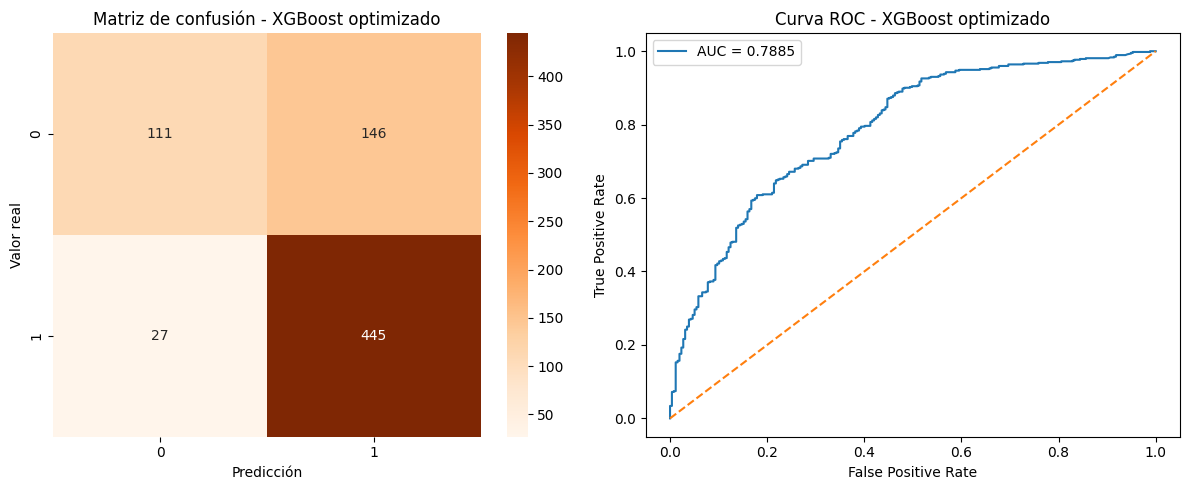

In [185]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - XGBoost optimizado")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {auc_xgb:.4f}"
)
ax[1].plot([0, 1], [0, 1], linestyle="--")
ax[1].set_title("Curva ROC - XGBoost optimizado")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **7.4 IMPORTANCIA DE VARIABLES**

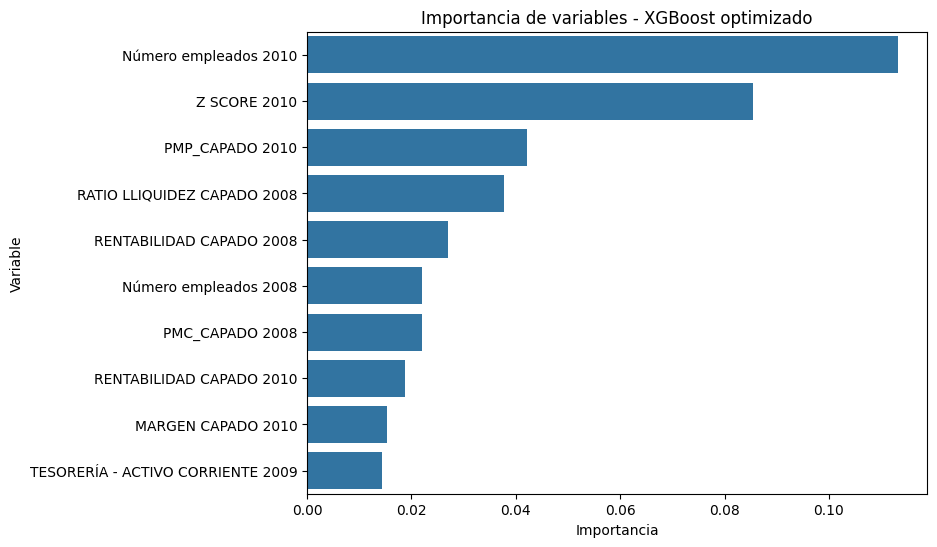

In [186]:
importancias_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": xgb_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

top10_xgb = importancias_xgb.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10_xgb,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - XGBoost optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## **8. RED NEURONAL**

## **8.1 DEFINICIÓN DE FUNCIONES:**


*   Definición de la arquitectura de la red
*   Capas ocultas y funciones de activación


*   Batch Normalization
*   Dropout

*   Capa de salida Softmax
*   Optimización del modelo

*   Función de pérdida


*   Regularización y ajuste de hiperparámetros








In [187]:
inicio_mlp = time.time()

def crear_mlp_credito(
    input_dim,
    arquitectura,
    learning_rate,
    dropout_rate,
    l2_rate
):

    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for neurons in arquitectura:
        model.add(Dense(
            neurons,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=l2(l2_rate)
        ))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

## **8.4 BÚSQUEDA DE HIPERPARÁMETROS**

In [188]:
resultados_mlp = []
arquitecturas = [
    [16, 8],
    [32, 16],
    [64, 32]
]
learning_rates = [0.001, 0.0005]
dropouts = [0.2, 0.3]
l2_rates = [0.001, 0.01]
batch_sizes = [16, 32]
thresholds = np.arange(0.01, 0.99, 0.01)

### **8.4.1 Selección del mejor modelo con los hiperparámetros**

In [189]:
for arquitectura in arquitecturas:

    for lr in learning_rates:

        for dropout in dropouts:

            for l2_rate in l2_rates:

                for batch_size in batch_sizes:

                    model = crear_mlp_credito(
                        input_dim=X_train_scaled.shape[1],
                        arquitectura=arquitectura,
                        learning_rate=lr,
                        dropout_rate=dropout,
                        l2_rate=l2_rate
                    )

                    early_stop = EarlyStopping(
                        monitor="val_loss",
                        patience=10,
                        restore_best_weights=True
                    )

                    reduce_lr = ReduceLROnPlateau(
                        monitor="val_loss",
                        factor=0.5,
                        patience=5,
                        min_lr=0.00001
                    )

                    history = model.fit(
                        X_train_scaled,
                        y_train,
                        validation_split=0.2,
                        epochs=100,
                        batch_size=batch_size,
                        callbacks=[early_stop, reduce_lr],
                        verbose=0
                    )

                    y_prob = model.predict(
                        X_test_scaled,
                        verbose=0
                    ).ravel()

                    for threshold in thresholds:

                        y_pred = (
                            y_prob >= threshold
                        ).astype(int)

                        resultados_mlp.append({
                            "Arquitectura": str(arquitectura),
                            "Learning Rate": lr,
                            "Dropout": dropout,
                            "L2": l2_rate,
                            "Batch Size": batch_size,
                            "Threshold": threshold,
                            "Accuracy": accuracy_score(y_test, y_pred),
                            "Precision": precision_score(y_test, y_pred, zero_division=0),
                            "Recall": recall_score(y_test, y_pred, zero_division=0),
                            "F1-score": f1_score(y_test, y_pred, zero_division=0),
                            "F2-score": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
                            "AUC-ROC": roc_auc_score(y_test, y_prob)
                        })

resultados_mlp_df = pd.DataFrame(resultados_mlp)

candidatos_mlp = resultados_mlp_df[
    resultados_mlp_df["Recall"] >= 0.95
]

if len(candidatos_mlp) > 0:
    mejor_mlp = candidatos_mlp.sort_values(
        by="Precision",
        ascending=False
    ).iloc[0]
else:
    mejor_mlp = resultados_mlp_df.sort_values(
        by="F2-score",
        ascending=False
    ).iloc[0]

print(mejor_mlp)

best_architecture = eval(mejor_mlp["Arquitectura"])
best_lr = mejor_mlp["Learning Rate"]
best_dropout = mejor_mlp["Dropout"]
best_l2 = mejor_mlp["L2"]
best_batch_size = int(mejor_mlp["Batch Size"])
best_threshold = mejor_mlp["Threshold"]

Arquitectura      [16, 8]
Learning Rate      0.0005
Dropout               0.3
L2                  0.001
Batch Size             32
Threshold            0.39
Accuracy         0.727023
Precision        0.717703
Recall            0.95339
F1-score         0.818926
F2-score         0.894632
AUC-ROC          0.755614
Name: 1312, dtype: object


## **8.5 ENTRENAMIENTO DEL MODELO CON LOS HIPERPARÁMETROS**

In [190]:
mlp_final = crear_mlp_credito(
    input_dim=X_train_scaled.shape[1],
    arquitectura=best_architecture,
    learning_rate=best_lr,
    dropout_rate=best_dropout,
    l2_rate=best_l2
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

history_mlp = mlp_final.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5406 - loss: 0.8117 - recall: 0.5282 - val_accuracy: 0.6827 - val_loss: 0.7000 - val_recall: 0.7573 - learning_rate: 5.0000e-04
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5844 - loss: 0.7708 - recall: 0.6040 - val_accuracy: 0.6947 - val_loss: 0.6837 - val_recall: 0.8179 - learning_rate: 5.0000e-04
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6093 - loss: 0.7256 - recall: 0.6605 - val_accuracy: 0.7118 - val_loss: 0.6701 - val_recall: 0.8681 - learning_rate: 5.0000e-04
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6170 - loss: 0.7242 - recall: 0.6930 - val_accuracy: 0.7136 - val_loss: 0.6588 - val_recall: 0.9050 - learning_rate: 5.0000e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6312 - loss: 0.7075 - recall: 0.7336 - val_accuracy: 0.7136 - val_loss: 0.6510 - val_recall: 0.9288 - learning_rate: 5.0000e-04
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━

## **8.6 CURVA DE COSTE**

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(
    history_mlp.history["loss"],
    label="Train loss"
)
plt.plot(
    history_mlp.history["val_loss"],
    label="Validation loss"
)
plt.title("Evolución de la función de coste")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

## **8.7 PREDICCIONES Y MÉTRICAS**

In [191]:
y_prob_mlp = mlp_final.predict(
    X_test_scaled
).ravel()

y_pred_mlp = (
    y_prob_mlp >= best_threshold
).astype(int)

tiempo_mlp = time.time() - inicio_mlp


accuracy_mlp = accuracy_score(
    y_test,
    y_pred_mlp
)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp,
    zero_division=0
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp,
    zero_division=0
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp,
    zero_division=0
)

f2_mlp = fbeta_score(
    y_test,
    y_pred_mlp,
    beta=2,
    zero_division=0
)

auc_mlp = roc_auc_score(
    y_test,
    y_prob_mlp
)

print("===== RED NEURONAL MLP =====\n")

print("Mejor arquitectura:", best_architecture)
print("Learning rate:", best_lr)
print("Dropout:", best_dropout)
print("L2:", best_l2)
print("Batch size:", best_batch_size)
print("Threshold:", best_threshold)

print("\nAccuracy:", accuracy_mlp)
print("Precision:", precision_mlp)
print("Recall:", recall_mlp)
print("F1-score:", f1_mlp)
print("F2-score:", f2_mlp)
print("AUC-ROC:", auc_mlp)
print("Tiempo (s):", tiempo_mlp)

print("\n===== Classification Report =====\n")

print(
    classification_report(
        y_test,
        y_pred_mlp,
        zero_division=0
    )
)
resultados_finales.append({
    "Modelo": "Red Neuronal MLP",
    "Accuracy": accuracy_mlp,
    "Precision": precision_mlp,
    "Recall": recall_mlp,
    "F1-score": f1_mlp,
    "F2-score": f2_mlp,
    "AUC-ROC": auc_mlp,
    "Tiempo (s)": tiempo_mlp
})

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
===== RED NEURONAL MLP =====

Mejor arquitectura: [16, 8]
Learning rate: 0.0005
Dropout: 0.3
L2: 0.001
Batch size: 32
Threshold: 0.39

Accuracy: 0.7407407407407407
Precision: 0.7386172006745363
Recall: 0.9279661016949152
F1-score: 0.8225352112676056
F2-score: 0.8827085852478839
AUC-ROC: 0.7592330013849502
Tiempo (s): 1551.0276181697845

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.75      0.40      0.52       257
           1       0.74      0.93      0.82       472

    accuracy                           0.74       729
   macro avg       0.74      0.66      0.67       729
weighted avg       0.74      0.74      0.72       729



## **8.8 MATRIZ DE CONFUSIÓN Y CURVA ROC**

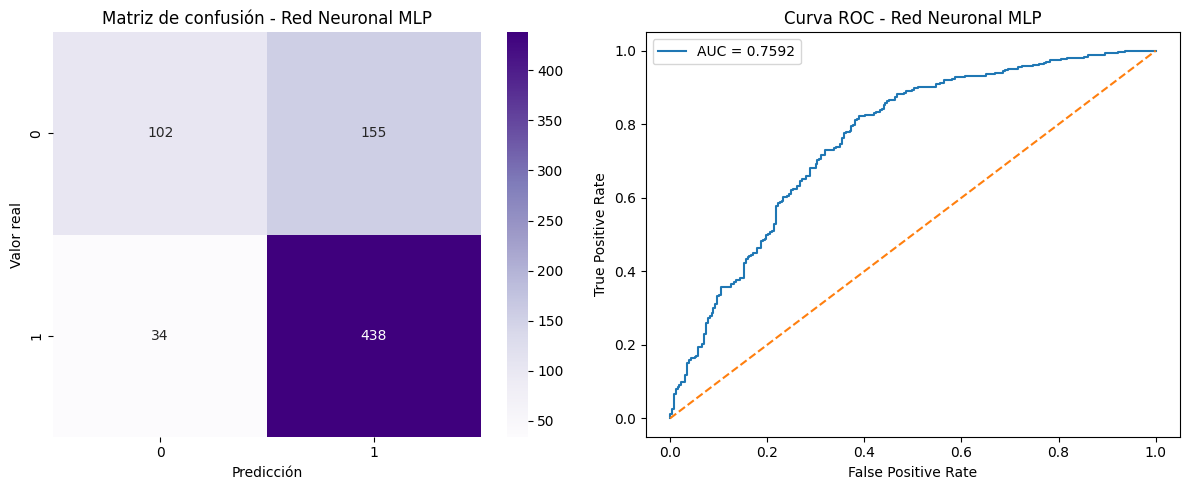

In [192]:
cm_mlp = confusion_matrix(y_test,y_pred_mlp)

fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(
    y_test,
    y_prob_mlp)

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Purples",
    ax=ax[0]
)

ax[0].set_title(
    "Matriz de confusión - Red Neuronal MLP"
)

ax[0].set_xlabel("Predicción")

ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_mlp,
    tpr_mlp,
    label=f"AUC = {auc_mlp:.4f}"
)

ax[1].plot(
    [0,1],
    [0,1],
    linestyle="--"
)

ax[1].set_title(
    "Curva ROC - Red Neuronal MLP"
)

ax[1].set_xlabel(
    "False Positive Rate"
)

ax[1].set_ylabel(
    "True Positive Rate"
)

ax[1].legend()

plt.tight_layout()

plt.show()

# **9. COMPARACIÓN DE MODELOS**

In [194]:
tabla_resultados = pd.DataFrame(resultados_finales)

tabla_resultados["Interpretabilidad"] = [
    "Sí",   # Regresión Logística
    "No",   # k-NN
    "Sí",   # Árbol
    "Sí",   # Random Forest
    "Sí",   # XGBoost
    "No"    # Red neuronal
]

tabla_resultados = tabla_resultados.sort_values(
    by="F2-score",
    ascending=False
)

tabla_resultados = tabla_resultados.reset_index(drop=True)

tabla_resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,F2-score,AUC-ROC,Tiempo (s),Interpretabilidad
0,Random Forest,0.7517,0.7397,0.9513,0.8323,0.8998,0.7837,240.8275,Sí
1,XGBoost,0.7627,0.7530,0.9428,0.8373,0.8975,0.7885,152.3561,Sí
2,Red Neuronal MLP,0.7407,0.7386,0.9280,0.8225,0.8827,0.7592,1551.0276,No
3,k-NN,0.7572,0.7639,0.9047,0.8283,0.8725,0.7370,16.3251,No
4,Árbol de Decisión,0.7599,0.7676,0.9025,0.8296,0.8719,0.7318,98.2394,Sí
5,Regresión Logística,0.7257,0.7353,0.9004,0.8095,0.8617,0.7146,1.3507,Sí
